### install requirements

In [2]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


### run training

In [ ]:
## datapath: mvtec ad dataset structure, put downloaded foreground masks in this file folder, named fg_mask
## augpath: augmented dtd dataset
## results_path: where the results are saved
## /mlruns: where mlflow tracking results are saved by default
## meta_epochs: 640 (set to be 5 here for faster training, 100 maybe enough)

In [13]:
%cd data/mvtec_ad
!ls
%cd ../..

/home/ting/GLASS/data/mvtec_ad
capsule  fg_mask  pill	screw
/home/ting/GLASS/data


In [10]:
%%bash

datapath=./data/mvtec_ad
augpath=./data/dtd/images
classes=('capsule' 'pill' 'screw')
flags=($(for class in "${classes[@]}"; do echo '-d '"${class}"; done))

python main.py \
    --results_path ./results \
    --gpu 0 \
    --seed 0 \
    --test ckpt \
  net \
    -b wideresnet50 \
    -le layer2 \
    -le layer3 \
    --pretrain_embed_dimension 1536 \
    --target_embed_dimension 1536 \
    --patchsize 3 \
    --meta_epochs 5 \
    --eval_epochs 1 \
    --dsc_layers 2 \
    --dsc_hidden 1024 \
    --pre_proj 1 \
    --mining 1 \
    --noise 0.015 \
    --radius 0.75 \
    --p 0.5 \
    --step 20 \
    --limit 392 \
  dataset \
    --distribution 0 \
    --mean 0.5 \
    --std 0.1 \
    --fg 1 \
    --rand_aug 1 \
    --batch_size 16 \
    --resize 288 \
    --imagesize 288 "${flags[@]}" mvtec $datapath $augpath

INFO:__main__:Command line arguments: main.py --results_path ./results --gpu 0 --seed 0 --test ckpt net -b wideresnet50 -le layer2 -le layer3 --pretrain_embed_dimension 1536 --target_embed_dimension 1536 --patchsize 3 --meta_epochs 5 --eval_epochs 1 --dsc_layers 2 --dsc_hidden 1024 --pre_proj 1 --mining 1 --noise 0.015 --radius 0.75 --p 0.5 --step 20 --limit 392 dataset --distribution 0 --mean 0.5 --std 0.1 --fg 1 --rand_aug 1 --batch_size 16 --resize 288 --imagesize 288 -d capsule -d pill -d screw mvtec ./data/mvtec_ad ./data/dtd/images
INFO:__main__:Dataset       CAPSULE       : train=219 test=132
INFO:__main__:Dataset         PILL        : train=267 test=167
INFO:__main__:Dataset        SCREW        : train=320 test=160
INFO:__main__:Selecting dataset [mvtec_capsule] (1/3) 2025-02-08 14:00:03
2025/02/08 14:00:03 INFO mlflow.tracking.fluent: Experiment with name 'GLASS_Training' does not exist. Creating a new experiment.


epoch:0 discriminator loss:2.06e+00 pt:79.13 pf:17.47 rt:0.90 rg:1.04 rf:3.40 svd:0 sample:219:   0%|          | 0/5 [00:23<?, ?epoch/s]
Inferring...: 100%|██████████| 9/9 [00:04<00:00,  2.43batch/s]
epoch:1 discriminator loss:1.71e+00 pt:91.57 pf:9.84 rt:0.90 rg:1.03 rf:3.42 svd:0 sample:219 IAUC:70.48(70.48) PAUC:71.44(71.44) IF1-max:90.83(90.83) E:0(0):  20%|██        | 1/5 [01:05<02:45, 41.33s/epoch] 
Inferring...:  89%|████████▉ | 8/9 [00:05<00:00,  1.54batch/s]
epoch:2 discriminator loss:1.61e+00 pt:92.98 pf:10.36 rt:0.89 rg:1.03 rf:3.42 svd:0 sample:219 IAUC:77.94(77.94) PAUC:81.17(81.17) IF1-max:91.14(91.14) E:1(1):  40%|████      | 2/5 [01:50<02:09, 43.17s/epoch]
Inferring...: 100%|██████████| 9/9 [00:04<00:00,  2.97batch/s]
epoch:3 discriminator loss:1.56e+00 pt:97.46 pf:7.14 rt:0.89 rg:1.03 rf:3.47 svd:0 sample:219 IAUC:93.66(93.66) PAUC:88.05(88.05) IF1-max:94.64(94.64) E:2(2):  60%|██████    | 3/5 [02:34<01:27, 43.77s/epoch] 
Inferring...:  89%|████████▉ | 8/9 [00:05<00:00

image_auroc:94.65 image_ap:98.78 pixel_auroc:94.98 pixel_ap:36.96 pixel_pro:88.44 image_f1_max:96.4 f1_max_threshold:15.21 best_epoch:4




epoch:0 discriminator loss:1.50e+00 pt:87.40 pf:45.99 rt:1.57 rg:1.61 rf:3.23 svd:1 sample:267:   0%|          | 0/5 [00:28<?, ?epoch/s]
Inferring...: 100%|██████████| 11/11 [00:06<00:00,  2.48batch/s]
epoch:1 discriminator loss:1.31e+00 pt:91.69 pf:46.61 rt:1.54 rg:1.58 rf:3.18 svd:1 sample:267 IAUC:74.6(74.6) PAUC:83.04(83.04) IF1-max:91.56(91.56) E:0(0):  20%|██        | 1/5 [01:20<03:22, 50.58s/epoch]
Inferring...: 100%|██████████| 11/11 [00:06<00:00,  2.57batch/s]
epoch:2 discriminator loss:1.22e+00 pt:91.69 pf:50.59 rt:1.51 rg:1.55 rf:3.14 svd:1 sample:267 IAUC:80.85(80.85) PAUC:91.89(91.89) IF1-max:92.0(92.0) E:1(1):  40%|████      | 2/5 [02:13<02:36, 52.05s/epoch]
Inferring...: 100%|██████████| 11/11 [00:06<00:00,  2.38batch/s]
epoch:3 discriminator loss:1.18e+00 pt:91.75 pf:53.18 rt:1.49 rg:1.54 rf:3.06 svd:1 sample:267 IAUC:86.09(86.09) PAUC:94.36(94.36) IF1-max:92.72(92.72) E:2(2):  60%|██████    | 3/5 [03:06<01:45, 52.66s/epoch]
Inferring...: 100%|██████████| 11/11 [00:06<0

image_auroc:91.41 image_ap:98.43 pixel_auroc:95.11 pixel_ap:73.04 pixel_pro:94.31 image_f1_max:93.29 f1_max_threshold:23.28 best_epoch:4




epoch:0 discriminator loss:1.31e+00 pt:88.97 pf:56.93 rt:2.02 rg:2.13 rf:3.54 svd:1 sample:320:   0%|          | 0/5 [00:33<?, ?epoch/s]
Inferring...: 100%|██████████| 10/10 [00:05<00:00,  2.28batch/s]
epoch:1 discriminator loss:1.15e+00 pt:91.48 pf:53.58 rt:1.96 rg:2.08 rf:3.44 svd:1 sample:320 IAUC:49.95(49.95) PAUC:91.7(91.7) IF1-max:85.61(85.61) E:0(0):  20%|██        | 1/5 [01:26<03:31, 52.88s/epoch]
Inferring...: 100%|██████████| 10/10 [00:06<00:00,  2.27batch/s]
epoch:2 discriminator loss:1.09e+00 pt:90.58 pf:57.07 rt:1.91 rg:2.03 rf:3.46 svd:1 sample:320 IAUC:50.69(50.69) PAUC:91.16(91.16) IF1-max:85.3(85.3) E:1(1):  40%|████      | 2/5 [02:22<02:43, 54.57s/epoch]
Inferring...: 100%|██████████| 10/10 [00:06<00:00,  2.24batch/s]
epoch:3 discriminator loss:1.04e+00 pt:92.31 pf:57.30 rt:1.87 rg:2.00 rf:3.49 svd:1 sample:320 IAUC:48.72(50.69) PAUC:88.97(91.16) IF1-max:85.3(85.3) E:2(1):  60%|██████    | 3/5 [03:13<01:46, 53.01s/epoch]
Inferring...: 100%|██████████| 10/10 [00:06<00:

image_auroc:55.97 image_ap:80.51 pixel_auroc:91.17 pixel_ap:5.86 pixel_pro:71.81 image_f1_max:85.3 f1_max_threshold:0.0 best_epoch:3




### run test

In [11]:
%%bash

datapath=./data/mvtec_ad
augpath=./data/dtd/images
classes=('capsule' 'pill' 'screw')
flags=($(for class in "${classes[@]}"; do echo '-d '"${class}"; done))

python main.py \
    --results_path ./results \
    --gpu 0 \
    --seed 0 \
    --test test \
  net \
    -b wideresnet50 \
    -le layer2 \
    -le layer3 \
    --pretrain_embed_dimension 1536 \
    --target_embed_dimension 1536 \
    --patchsize 3 \
    --meta_epochs 5 \
    --eval_epochs 1 \
    --dsc_layers 2 \
    --dsc_hidden 1024 \
    --pre_proj 1 \
    --mining 1 \
    --noise 0.015 \
    --radius 0.75 \
    --p 0.5 \
    --step 20 \
    --limit 392 \
  dataset \
    --distribution 0 \
    --mean 0.5 \
    --std 0.1 \
    --fg 1 \
    --rand_aug 1 \
    --batch_size 16 \
    --resize 288 \
    --imagesize 288 "${flags[@]}" mvtec $datapath $augpath

INFO:__main__:Command line arguments: main.py --results_path ./results --gpu 0 --seed 0 --test test net -b wideresnet50 -le layer2 -le layer3 --pretrain_embed_dimension 1536 --target_embed_dimension 1536 --patchsize 3 --meta_epochs 5 --eval_epochs 1 --dsc_layers 2 --dsc_hidden 1024 --pre_proj 1 --mining 1 --noise 0.015 --radius 0.75 --p 0.5 --step 20 --limit 392 dataset --distribution 0 --mean 0.5 --std 0.1 --fg 1 --rand_aug 1 --batch_size 16 --resize 288 --imagesize 288 -d capsule -d pill -d screw mvtec ./data/mvtec_ad ./data/dtd/images
INFO:__main__:Dataset       CAPSULE       : train=0 test=132
INFO:__main__:Dataset         PILL        : train=0 test=167
INFO:__main__:Dataset        SCREW        : train=0 test=160
INFO:__main__:Selecting dataset [mvtec_capsule] (1/3) 2025-02-08 14:29:23


INFO:__main__:Selecting dataset [mvtec_pill] (2/3) 2025-02-08 14:30:03


image_auroc:94.65 image_ap:98.78 pixel_auroc:94.98 pixel_ap:36.96 pixel_pro:88.44 image_f1_max:96.4 f1_max_threshold:15.21 best_epoch:4




INFO:__main__:Selecting dataset [mvtec_screw] (3/3) 2025-02-08 14:30:56


image_auroc:91.41 image_ap:98.43 pixel_auroc:95.11 pixel_ap:73.04 pixel_pro:94.31 image_f1_max:93.29 f1_max_threshold:23.28 best_epoch:4


image_auroc:55.97 image_ap:80.51 pixel_auroc:91.17 pixel_ap:5.86 pixel_pro:71.81 image_f1_max:85.3 f1_max_threshold:0.0 best_epoch:3




### observe results

In [ ]:
## results/models: saved model weights
## eval: each image contains three parts from left to right: input image, groundtruth, predicted heatmap
## results.csv: evaluation results on all metrics for each category and the mean of them

In [18]:
%cd results
!ls

/home/ting/GLASS/results
eval  models  results.csv  training


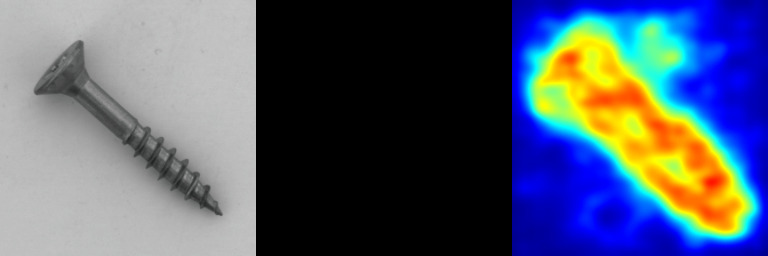

In [19]:
from IPython.display import Image, display
display(Image('eval/mvtec_screw/001.png'))